In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

c:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


In [ ]:
fluorophores = fl.construct_fluorophores(
    name="cy5_gidi_dna", distance=10, count=1, shape="square"
)

fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    irradiance=2.5,
    wavelength=640,
    bleaching=True,
    energy_transfer=False,
    dstorm=True,
    reducing_agent="mea",
    concentration=100,
    ph=7.5,
)
transitions['cy5_gidi_dna'].extend([tr.Transition(tr.TransitionType.RAD_ESCAPE, 8e5, [0]),
                    tr.Transition(tr.TransitionType.RAD_RELAX, 8e2, [0])])

transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates({4:2e+07, 5:5e4})
transition_set.finalize()

In [ ]:
transition_set.transition_df

transition_type abbreviation  \
Fluorophore  identity                                                        
cy5_gidi_dna 0                      TransitionType.EXCITATION          EXC   
             1            TransitionType.FLUORESCENT_EMISSION          FLU   
             2         TransitionType.INTERSYSTEM_CROSSING_ST        ISCST   
             3         TransitionType.INTERSYSTEM_CROSSING_TS        ISCTS   
             4                   TransitionType.ISOMERIZATION          ISO   
             5               TransitionType.BACKISOMERIZATION         BISO   
             6           TransitionType.INTERNAL_CONVERSION_S          ICS   
             7                      TransitionType.ET_CYCLE_T          ETT   
             8                      TransitionType.ET_CYCLE_S          ETS   
             9                     TransitionType.REDUCTION_T         REDT   
             10                    TransitionType.REDUCTION_S         REDS   
             11                    TransitionType.OXIDATION_1         OXI1   
             12               TransitionType.PHOTOBLEACHING_1         BLE1   
             13                     TransitionType.RAD_ESCAPE           RE   
             14                      TransitionType.RAD_RELAX           RR   

                          initial_state       final_state          rate  \
Fluorophore  identity                                                     
cy5_gidi_dna 0           SingleState.S0    SingleState.S1  7.269626e+06   
             1           SingleState.S1    SingleState.S0  2.700000e+08   
             2           SingleState.S1    SingleState.T1  8.300000e+05   
             3           SingleState.T1    SingleState.S0  5.000000e+03   
             4           SingleState.S1   SingleState.Cis  2.000000e+07   
             5          SingleState.Cis    SingleState.S0  1.300000e+05   
             6           SingleState.S1    SingleState.S0  7.251700e+08   
             7           SingleState.T1    SingleState.S0  7.358756e+05   
             8           SingleState.S1    SingleState.S0  7.358756e+06   
             9           SingleState.T1  SingleState.OFF1  7.358756e+02   
             10          SingleState.S1  SingleState.OFF1  7.358756e+03   
             11        SingleState.OFF1    SingleState.S0  2.000000e-02   
             12          SingleState.T1     SingleState.B  1.000000e+01   
             13          SingleState.T1   SingleState.Rad  8.000000e+05   
             14         SingleState.Rad    SingleState.S0  8.000000e+02   

                       photon fluorophore_ids  absorbing  
Fluorophore  identity                                     
cy5_gidi_dna 0          False             [0]      False  
             1           True             [0]      False  
             2          False             [0]      False  
             3          False             [0]      False  
             4          False             [0]      False  
             5          False             [0]      False  
             6          False             [0]      False  
             7          False             [0]      False  
             8          False             [0]      False  
             9          False             [0]      False  
             10         False             [0]      False  
             11         False             [0]      False  
             12         False             [0]       True  
             13         False             [0]      False  
             14         False             [0]      False

In [ ]:
rng = np.random.default_rng(10)
simulation = si.Simulation(transition_set=transition_set)
simulation.run(size=1e6, end_time=5000, seed=rng)
emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=100)

In [ ]:
emis.extract(simulation)
photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
emis.add_photon_collection_objective(p=photon_collection_rate, seed=100)
emis.add_transmittance(p=0.9, seed=100)  # 90/10 mirror
emis.add_quantum_efficiency(p=0.85, seed=100)  # SPAD
emis.add_poisson_noise(rate=0.6, seed=100)  # dark noise
emis.apply_threshold(threshold=10)

array([[<AxesSubplot:title={'center':'intensity distribution'}, xlabel='photon count', ylabel='PD'>]],
      dtype=object)

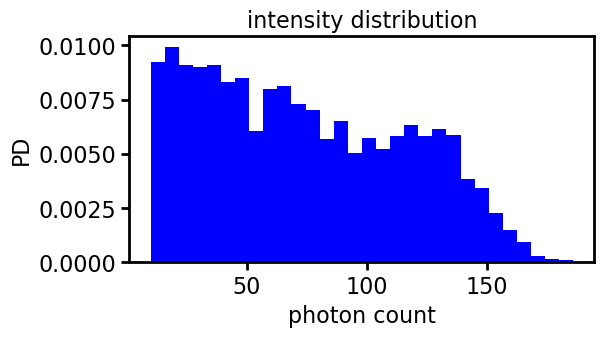

In [ ]:
emis.plot_histogram(bins=30)

In [62]:
fluorophores = fl.construct_fluorophores(
    name="cy5_gidi_dna", distance=10, count=1, shape="square"
)

fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    irradiance=2.5,
    wavelength=640,
    bleaching=True,
    energy_transfer=False,
    dstorm=True,
    reducing_agent="mea",
    concentration=100,
    ph=7.5,
)
transitions['cy5_gidi_dna'].extend([tr.Transition(tr.TransitionType.RAD_ESCAPE, 8e5, [0]),
                    tr.Transition(tr.TransitionType.RAD_RELAX, 8e2, [0])])

transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates({4:2e+07, 5:1.3e5})
transition_set.finalize()

In [63]:
transition_set.transition_df

transition_type abbreviation  \
Fluorophore  identity                                                        
cy5_gidi_dna 0                      TransitionType.EXCITATION          EXC   
             1            TransitionType.FLUORESCENT_EMISSION          FLU   
             2         TransitionType.INTERSYSTEM_CROSSING_ST        ISCST   
             3         TransitionType.INTERSYSTEM_CROSSING_TS        ISCTS   
             4                   TransitionType.ISOMERIZATION          ISO   
             5               TransitionType.BACKISOMERIZATION         BISO   
             6           TransitionType.INTERNAL_CONVERSION_S          ICS   
             7                      TransitionType.ET_CYCLE_T          ETT   
             8                      TransitionType.ET_CYCLE_S          ETS   
             9                     TransitionType.REDUCTION_T         REDT   
             10                    TransitionType.REDUCTION_S         REDS   
             11                    TransitionType.OXIDATION_1         OXI1   
             12               TransitionType.PHOTOBLEACHING_1         BLE1   
             13                     TransitionType.RAD_ESCAPE           RE   
             14                      TransitionType.RAD_RELAX           RR   

                          initial_state       final_state          rate  \
Fluorophore  identity                                                     
cy5_gidi_dna 0           SingleState.S0    SingleState.S1  7.269626e+06   
             1           SingleState.S1    SingleState.S0  2.700000e+08   
             2           SingleState.S1    SingleState.T1  8.300000e+05   
             3           SingleState.T1    SingleState.S0  5.000000e+03   
             4           SingleState.S1   SingleState.Cis  2.000000e+07   
             5          SingleState.Cis    SingleState.S0  1.300000e+05   
             6           SingleState.S1    SingleState.S0  7.251700e+08   
             7           SingleState.T1    SingleState.S0  7.358756e+05   
             8           SingleState.S1    SingleState.S0  7.358756e+06   
             9           SingleState.T1  SingleState.OFF1  7.358756e+02   
             10          SingleState.S1  SingleState.OFF1  7.358756e+03   
             11        SingleState.OFF1    SingleState.S0  2.000000e-02   
             12          SingleState.T1     SingleState.B  1.000000e+01   
             13          SingleState.T1   SingleState.Rad  8.000000e+05   
             14         SingleState.Rad    SingleState.S0  8.000000e+02   

                       photon fluorophore_ids  absorbing  
Fluorophore  identity                                     
cy5_gidi_dna 0          False             [0]      False  
             1           True             [0]      False  
             2          False             [0]      False  
             3          False             [0]      False  
             4          False             [0]      False  
             5          False             [0]      False  
             6          False             [0]      False  
             7          False             [0]      False  
             8          False             [0]      False  
             9          False             [0]      False  
             10         False             [0]      False  
             11         False             [0]      False  
             12         False             [0]       True  
             13         False             [0]      False  
             14         False             [0]      False

In [64]:
rng = np.random.default_rng(10)
simulation = si.Simulation(transition_set=transition_set)
simulation.run(size=1e6, end_time=5000, seed=rng)
emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=100)

In [65]:
emis.extract(simulation)
photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
emis.add_photon_collection_objective(p=photon_collection_rate, seed=100)
emis.add_transmittance(p=0.9, seed=100)  # 90/10 mirror
emis.add_quantum_efficiency(p=0.85, seed=100)  # SPAD
emis.add_poisson_noise(rate=0.6, seed=100)  # dark noise
emis.apply_threshold(threshold=10)

array([[<AxesSubplot:title={'center':'intensity distribution'}, xlabel='photon count', ylabel='PD'>]],
      dtype=object)

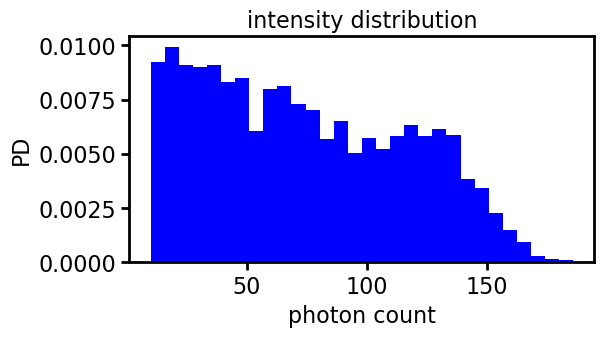

In [66]:
emis.plot_histogram(bins=30)

In [57]:
rng = np.random.default_rng(10)
simulation = si.Simulation(transition_set=transition_set)
simulation.run(size=1e6, end_time=5000, seed=rng)
emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=100)

In [58]:
emis.extract(simulation)
photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
emis.add_photon_collection_objective(p=photon_collection_rate, seed=100)
emis.add_transmittance(p=0.9, seed=100)  # 90/10 mirror
emis.add_quantum_efficiency(p=0.85, seed=100)  # SPAD
emis.add_poisson_noise(rate=0.6, seed=100)  # dark noise
emis.apply_threshold(threshold=10)

array([[<AxesSubplot:title={'center':'intensity distribution'}, xlabel='photon count', ylabel='PD'>]],
      dtype=object)

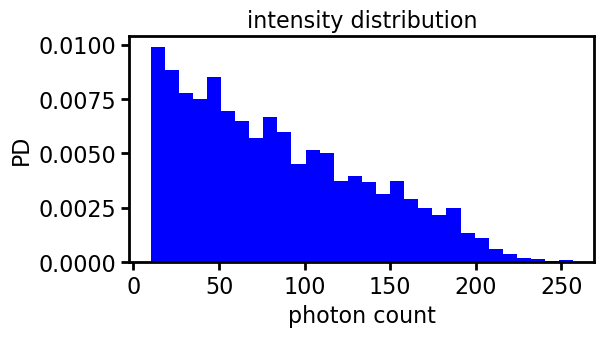

In [59]:
emis.plot_histogram(bins=30)

array([[<AxesSubplot:title={'center':'fluorescence trajectory'}, xlabel='time [s]', ylabel='photon count'>]],
      dtype=object)

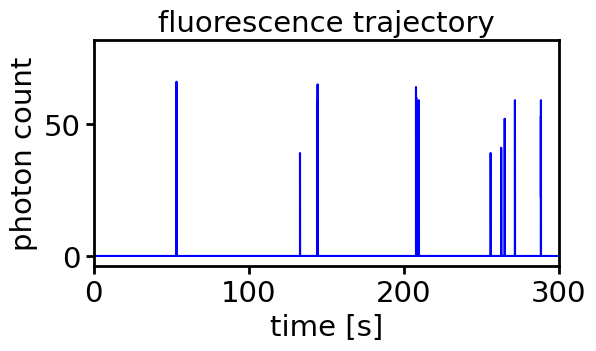

In [36]:
emis.plot_time_series(xlim=[0, 300])

array([[<AxesSubplot:title={'center':'intensity distribution'}, xlabel='photon count', ylabel='PD'>]],
      dtype=object)

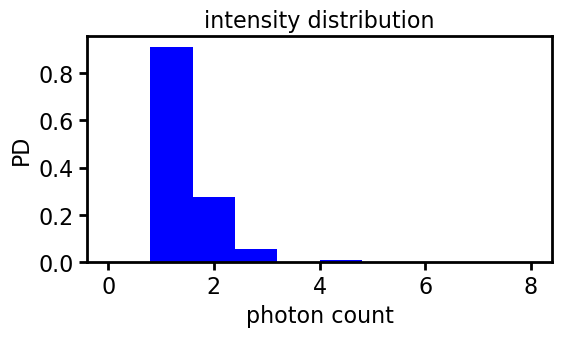

In [38]:
emis.plot_histogram(range=[0, 8])

In [11]:
blinks = bl.Blinking(emis, memory=10)

array([[<AxesSubplot:title={'center':'ON periods'}, xlabel='x', ylabel='time [ms]'>]],
      dtype=object)

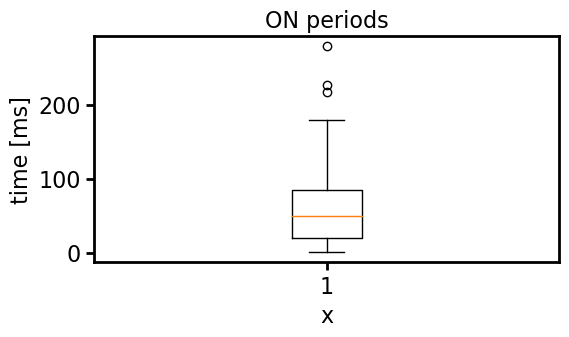

In [6]:
blinks.plot('on_boxplot', as_time='ms')

array([[<AxesSubplot:title={'center':'OFF periods'}, xlabel='x', ylabel='time [s]'>]],
      dtype=object)

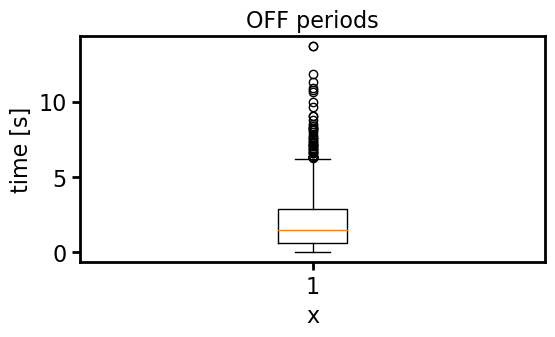

In [12]:
blinks.plot('off_boxplot', as_time='s')

array([[<AxesSubplot:title={'center':'intensity distribution'}, xlabel='photon count', ylabel='PD'>]],
      dtype=object)

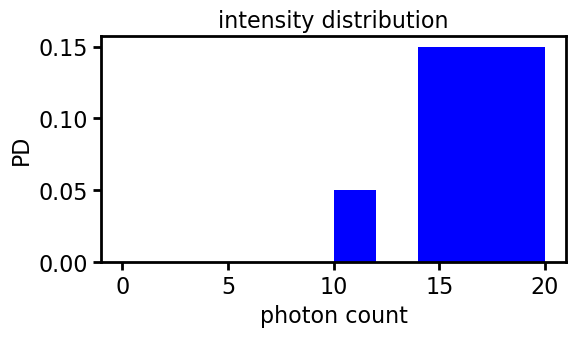

In [38]:
emis.plot_histogram(range=[0, 20])

In [133]:
np.unique(blinks.off_periods, return_counts=True)

(array([   370,    507,    778,   1143,   1253,   1465,   1603,   2244,
          2500,   2757,   2901,   3063,   3423,   3595,   3856,   3861,
          4481,   4720,   4942,   4984,   6696,   6744,   7558,   7992,
          8493,   8533,   8601,   8749,   9011,   9058,   9219,   9278,
          9444,   9754,   9873,  10355,  10377,  10396,  10430,  10799,
         10821,  11335,  11668,  11828,  12112,  13332,  13468,  13686,
         13877,  13979,  14157,  14377,  14405,  15151,  16127,  16156,
         17052,  17301,  18001,  18202,  18883,  18924,  19028,  20818,
         21350,  22546,  23087,  23578,  23597,  23943,  24058,  24095,
         24114,  24445,  24760,  25095,  25357,  26836,  27111,  27339,
         27548,  28114,  28672,  29063,  29805,  32733,  32786,  33213,
         34942,  35129,  35432,  35467,  37011,  39257,  39720,  40178,
         42000,  43804,  43819,  44422,  44685,  45157,  46379,  46923,
         47036,  47252,  47398,  47560,  48843,  51837,  52178, 

In [132]:
blinks = bl.Blinking(emis, memory=10)

In [134]:
blinks.on_periods

array([ 70,  57, 259,  25,  70, 104,  22,  35,  60,  24,  27,  58, 105,
        24,  37,  40,  44,  11,  97,   8,  45,  40, 208,  49,  55, 135,
       165, 125,  51,  71,  64,  33,  66,  74,  54, 124, 203,  85,   6,
         3, 274,  17,  46,  77,  74,  25,  62, 113,  65,  21,  19, 158,
        92,   2, 176,  40,  15,  14,  54, 107,  18,   9,  65,  64,  48,
       176, 295,  39, 186,  53,  40,  43,   6,   1,  39, 179, 145,   3,
        42,  41,  69,  24, 131, 180, 283,  52,   2,  34,  61,   2,  14,
       100,  32, 303, 162,   6,  35,   7,  21,  79,  45,  37,  72,  69,
        29,  94,  63,   5,  12,  52,  44,  27,  23, 253,  72,  46,   8,
        53,  64,  41,  92,  32, 129,  15,  83,  34,  92,  54,  92,   3,
        18, 173,  35,   8,  37, 345, 231,   7,   7, 101,  19,  17, 177,
        87,  41, 103,  68, 115,  69,  10,  25,  13,  30,  10,  78, 112,
        92,  30,  91,  39,  69,  30, 108,  95,  58, 227,  72,  45,  70,
       219,  74,  19,  56, 134,  92,  27, 278,  47,  78,  51,  9

array([[<AxesSubplot:title={'center':'ON periods'}, xlabel='consecutive frames', ylabel='PD'>]],
      dtype=object)

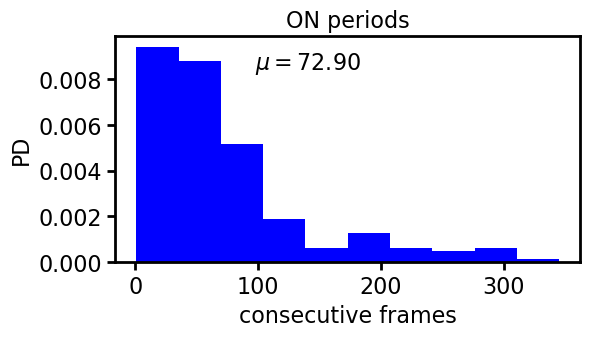

In [135]:
blinks.plot('on_histogram')

WARNING for line:         _, axes = plt.subplots(
 More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`. 


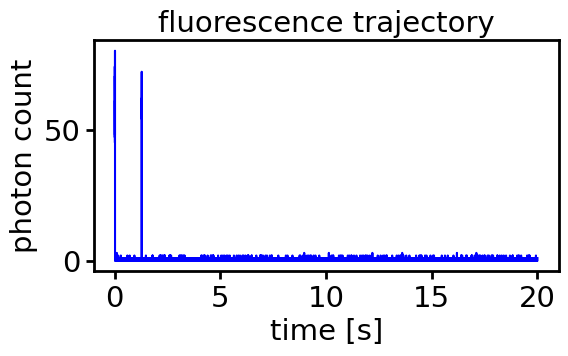

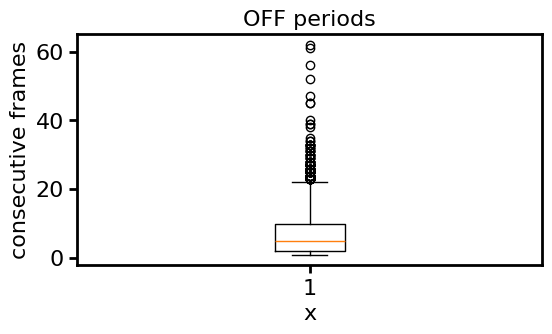

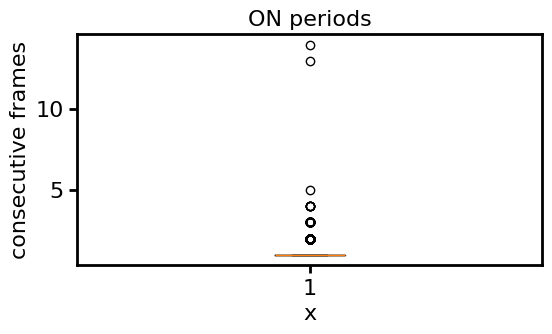

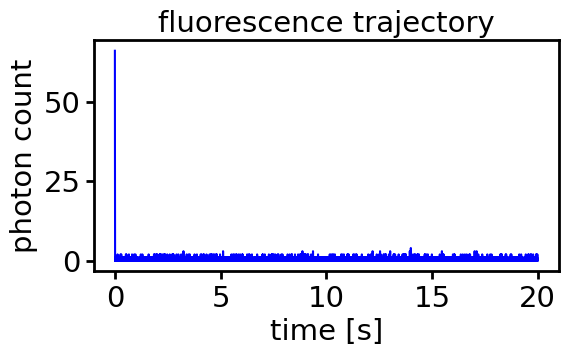

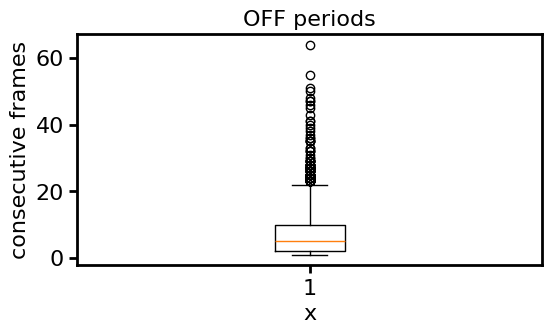

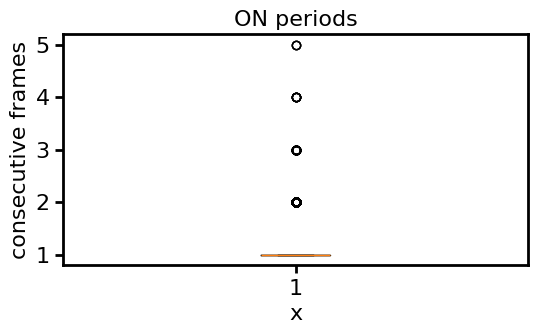

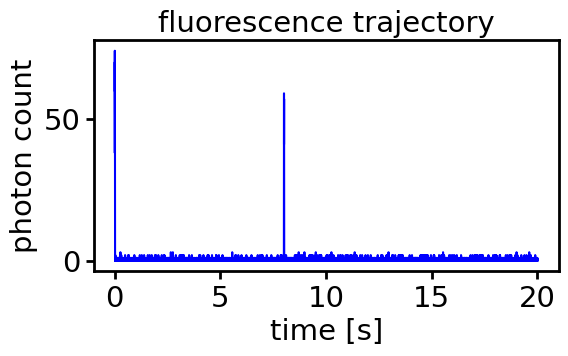

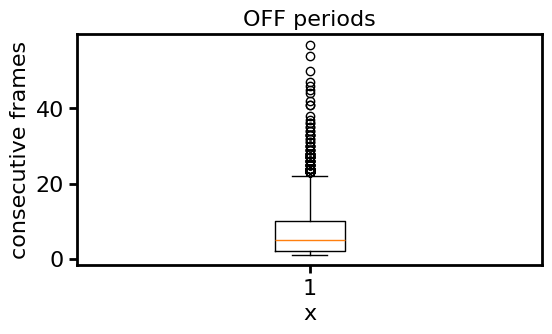

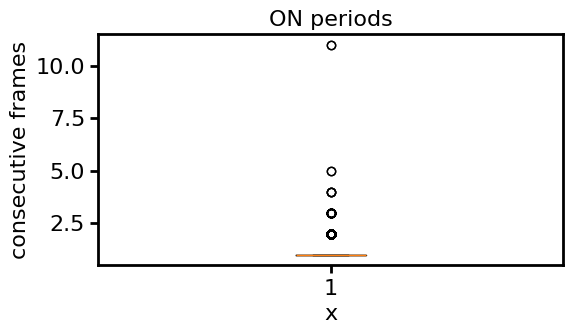

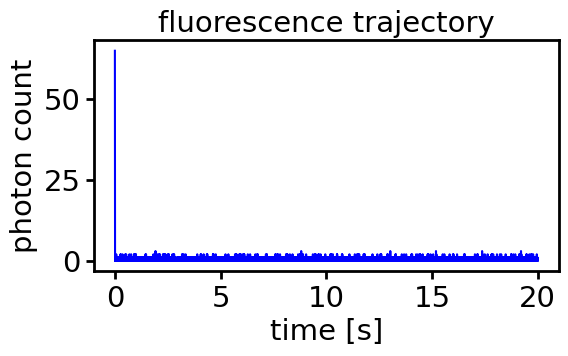

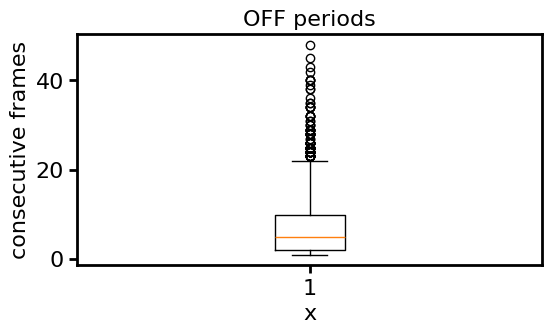

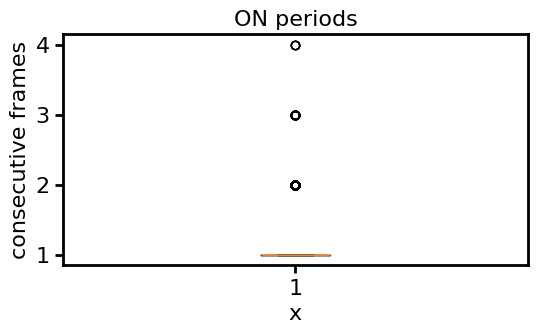

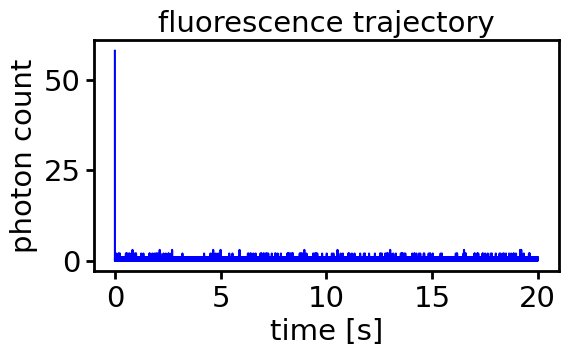

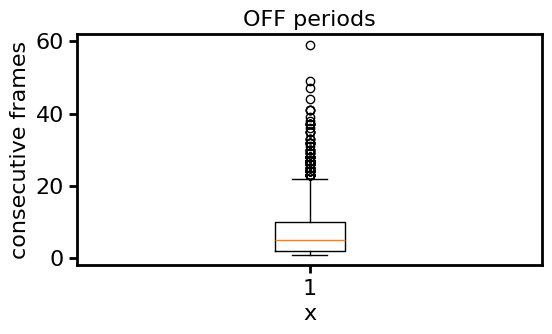

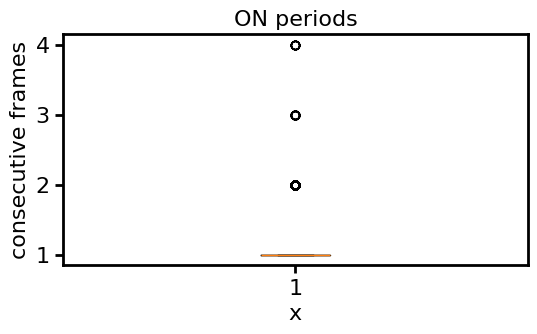

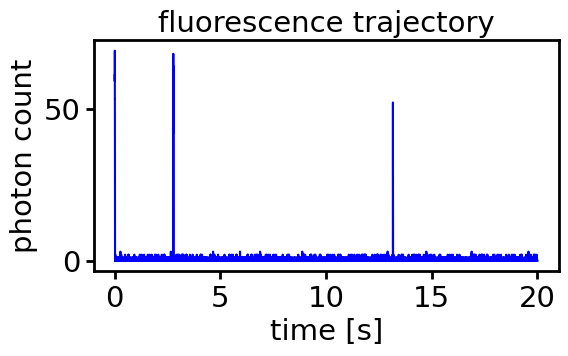

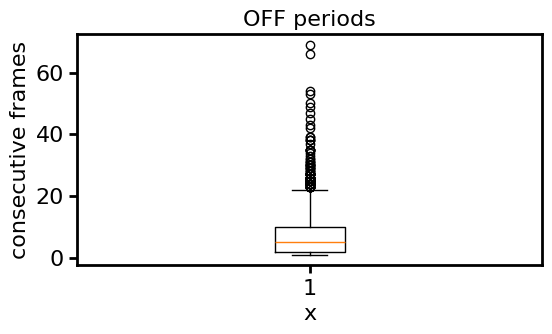

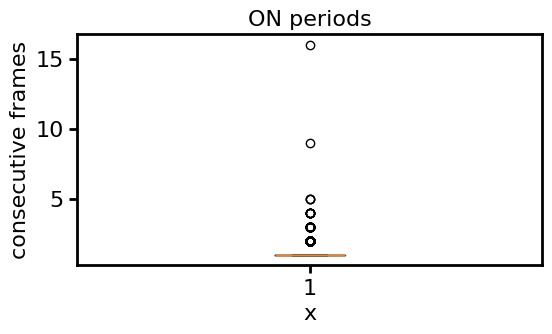

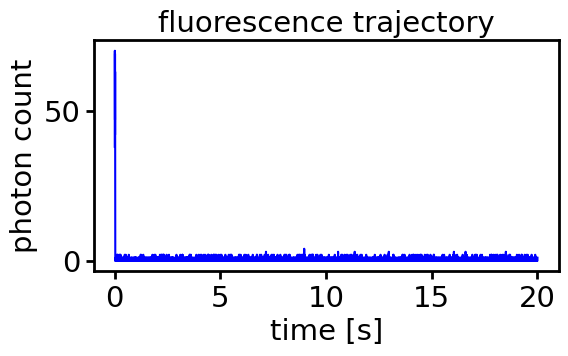

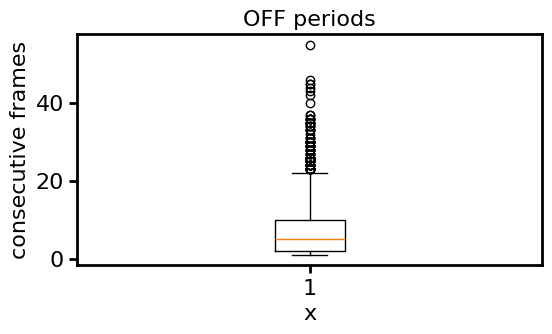

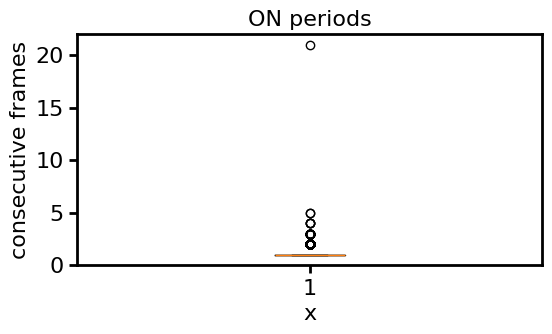

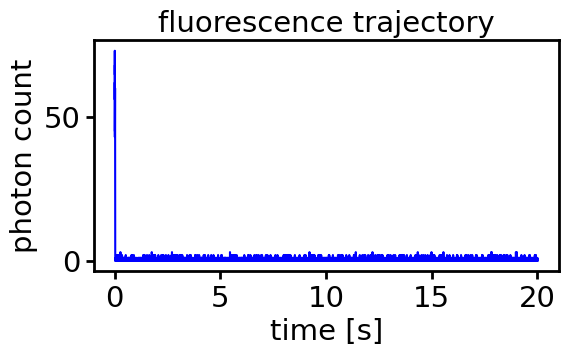

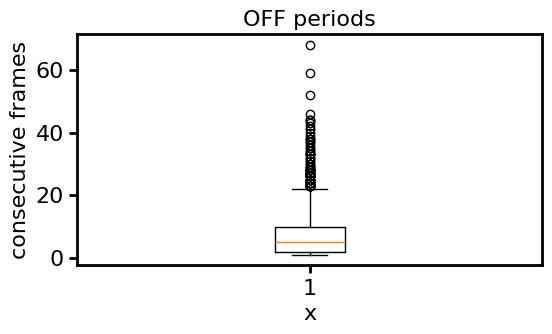

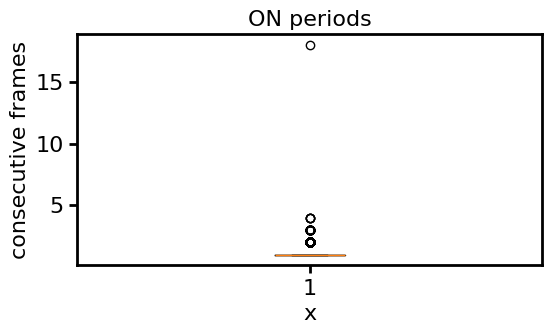

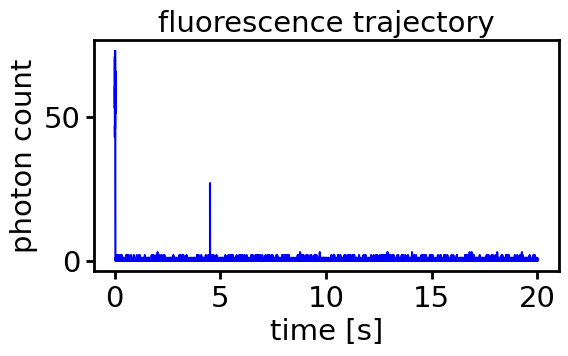

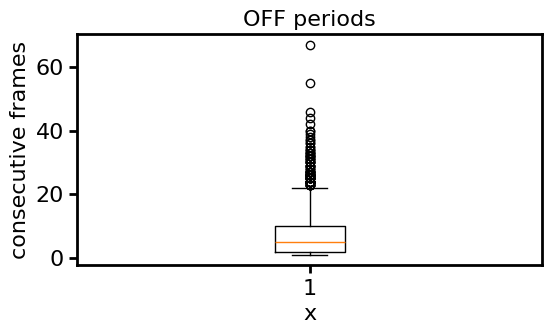

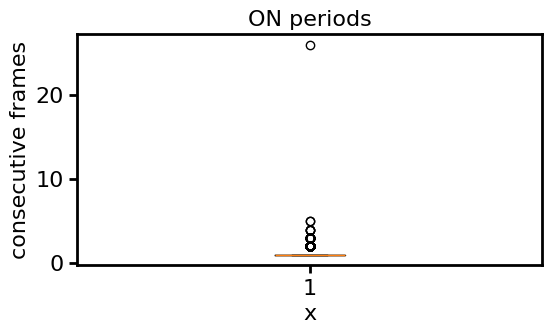

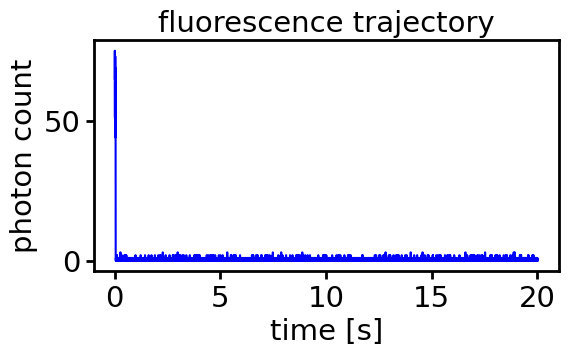

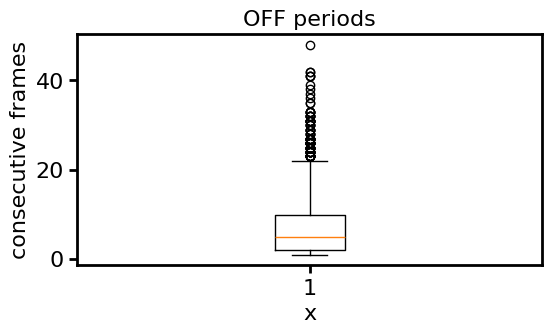

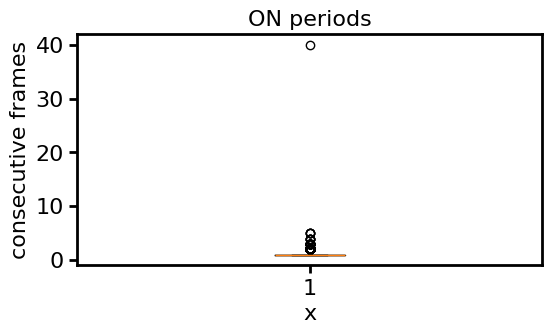

In [43]:
all_on_periods = []
all_off_periods = []
all_intensities = []
rng = np.random.default_rng(100)
for _ in range(10):
    simulation = si.Simulation(transition_set=transition_set)
    simulation.run(size=1e6, end_time=20, seed=rng)
    emis = em.Emissions(frame_time='1ms', bandpass=[655, 731], seed=100)
    emis.extract(simulation)
    photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
    emis.add_photon_collection_objective(p=photon_collection_rate, seed=100) 
    emis.add_quantum_efficiency(p=0.9, seed=100)
    emis.add_poisson_noise(rate=0.6, seed=100)
    emis.add_transmittance(p=0.25, seed=100)
    emis.plot_time_series()
    blinks = bl.Blinking(emis)
    all_intensities.append(emis.event_time_series[emis.event_time_series > 0])

    all_on_periods.append(blinks.on_periods)
    all_off_periods.append(blinks.off_periods)
    blinks.plot(mode='off_boxplot')
    blinks.plot(mode='on_boxplot')

In [17]:
all_intensities = pd.concat(all_intensities)

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

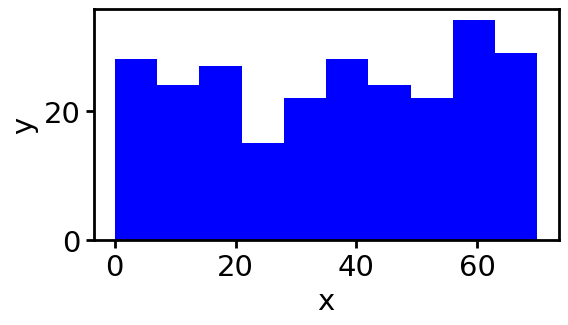

In [18]:
fi.universal_figure(data=all_intensities.values, type_='hist', range=[0, 70])

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

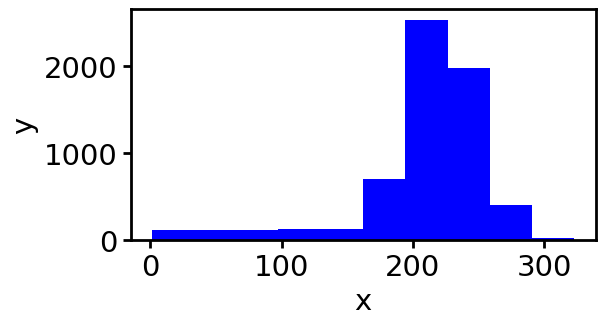

In [19]:
fi.universal_figure(data=all_intensities.values, type_='hist')

In [10]:
on_periods = np.concatenate(all_on_periods)
off_periods = np.concatenate(all_off_periods)

In [14]:
on_periods.mean()

14.904761904761905

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

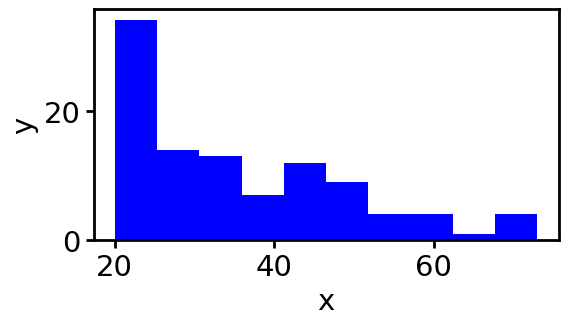

In [11]:
fi.universal_figure(type_='hist', data=on_periods, range=[20, max(on_periods)])

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

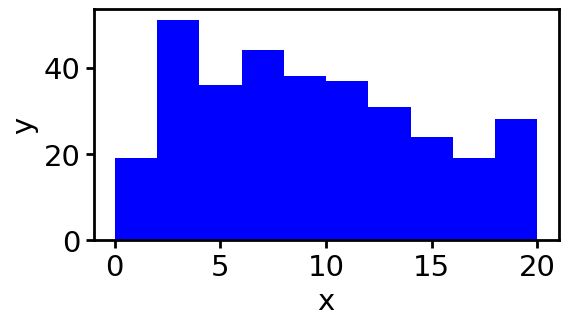

In [12]:
fi.universal_figure(type_='hist', data=on_periods, range=[0, 20])

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

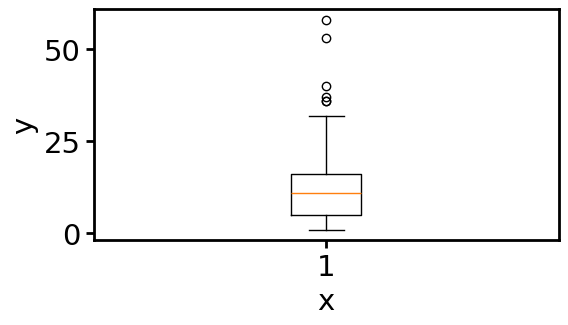

In [8]:
fi.universal_figure(type_='boxplot', data=on_periods)

In [20]:
off_periods

array([  1254,  61563,  47252,  24114,  95632,  35432, 103689,  13332,
         2900,  23575,  16874, 110501,  41999,  88209,  90010,  24057,
         9218,  28114,  68433, 116660, 109133,   1143,  45156,   7991,
        18924,  52970,  66496,  17052,  32786, 106016,  44421,   3060,
       242768,  32732,  91257,  20819,  10798, 113585,  52685, 128616,
        15150, 111425,  56471,  90478, 146429,   2756,  10376, 100522,
        24760,  53417, 107516,   9443,  21281, 120199,   9057, 117404,
        93878,  93106,  86844,   3595,  46378,  39257,  83341,  37011,
        72914,  46922,  63067,   4480,  86267,  16155,  11828, 246180,
        14156, 104970,  90127,  53905,  10355,  13467,  17300,   4720,
       156269, 111827,  51837,   9278,  42264,  18882,  47397,  18201,
        87606,  10822,  65259,   4942,  43804,  56934,  13876,  26836,
        44685, 254873,  52178,  35129,  12112,  13979,  29063,  34942,
        52498,    507,  18001,  11334,  23943,   1603,  56754,  40178,
      